In [ ]:
!pip install imbalanced-learn

In [ ]:
!pip install seaborn matplotlib imbalanced-learn numpy pandas tensorflow scikit-learn
!pip install seaborn matplotlib pandas

In [ ]:
!pip install --upgrade scikit-learn
!pip install --upgrade imbalanced-learn
!pip install scikit-learn==1.2.2 imbalanced-learn==0.10.1


  Using cached scikit_learn-1.5.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
Using cached scikit_learn-1.5.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.4 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Using cached imbalanced_learn-0.12.3-py3-none-any.whl.metadata (8.3 kB)
Using cached imbalanced_learn-0.12.3-py3-none-any.whl (258 kB)
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.10.1
    Uninstalling imbalanced-learn-0.10.1:
      Successfully uninstalled imbalanced-learn-0.10.1
  Using cached scikit_learn-1.2.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.10.1-py3-none-any.whl.metadata (8.2 kB)
Using cached scikit_learn-1.2.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (9.6 M

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPooling2D, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf

In [ ]:
data = pd.read_csv('hmnist_28_28_RGB.csv')
print("Data Loaded:")
print(f"HMNIST Data Shape: {data.shape}")
data.head()

Data Loaded:
HMNIST Data Shape: (454, 2353)


,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173.0,124.0,138.0,183.0,147.0,166.0,185.0,154.0,177.0,2.0
1,25,14,30,68,48,75,123,93,126,158,...,60.0,39.0,55.0,25.0,14.0,28.0,25.0,14.0,27.0,2.0
2,192,138,153,200,145,163,201,142,160,206,...,167.0,129.0,143.0,159.0,124.0,142.0,136.0,104.0,117.0,2.0
3,38,19,30,95,59,72,143,103,119,171,...,44.0,26.0,36.0,25.0,12.0,17.0,25.0,12.0,15.0,2.0
4,158,113,139,194,144,174,215,162,191,225,...,209.0,166.0,185.0,172.0,135.0,149.0,109.0,78.0,92.0,2.0


In [ ]:
data2 = pd.read_csv('ISIC_2020.csv')
print("Data Loaded:")
print(f"Data Shape: {data2.shape}")
data2.head()

Data Loaded:
Data Shape: (33126, 8)


,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0


In [ ]:
tabular_data = pd.read_csv('HAM10000_metadata.csv')
tabular_data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
classes = {
    0: ('akiec', 'Actinic keratoses and intraepithelial carcinomae'),
    1: ('bcc', 'basal cell carcinoma'),
    2: ('bkl', 'benign keratosis-like lesions'),
    3: ('df', 'dermatofibroma'),
    4: ('nv', 'melanocytic nevi'),
    5: ('vasc', 'pyogenic granulomas and hemorrhage'),
    6: ('mel', 'melanoma')
}

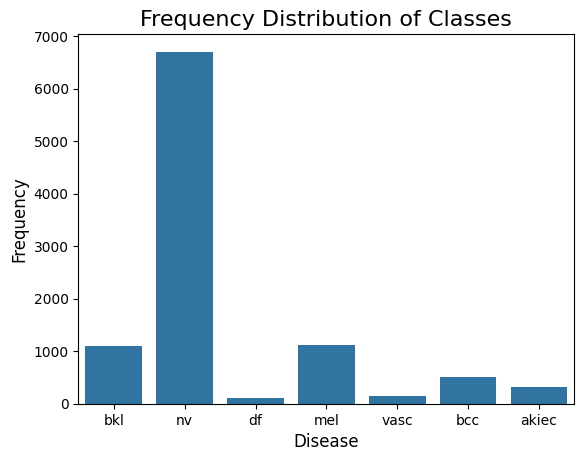

In [ ]:
sns.countplot(x='dx', data=tabular_data)
plt.xlabel('Disease', size=12)
plt.ylabel('Frequency', size=12)
plt.title('Frequency Distribution of Classes', size=16)
plt.show()

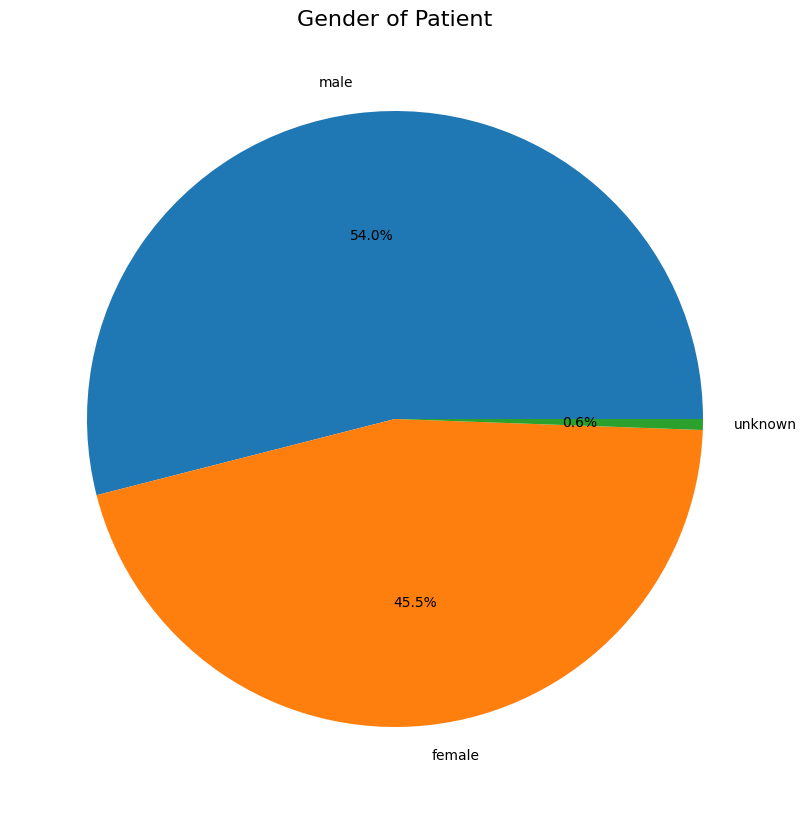

In [ ]:
plt.figure(figsize=(10,10))
plt.pie(tabular_data['sex'].value_counts(), labels=tabular_data['sex'].value_counts().index, autopct="%.1f%%")
plt.title('Gender of Patient', size=16)
plt.show()

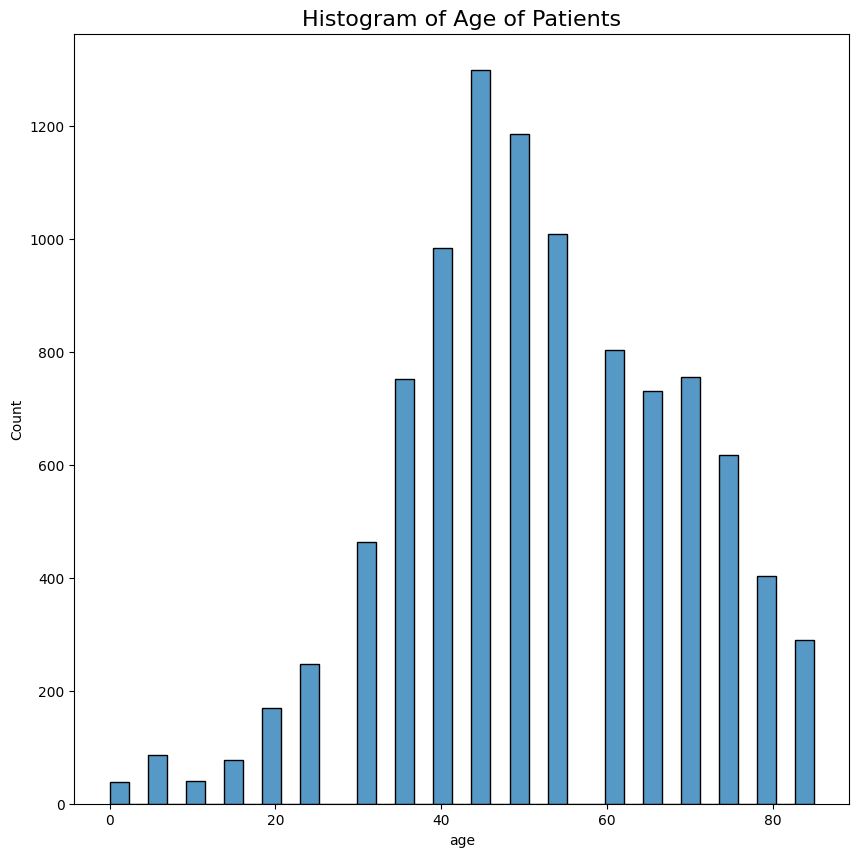

In [ ]:
plt.figure(figsize=(10,10))
sns.histplot(tabular_data['age'])
plt.title('Histogram of Age of Patients', size=16)
plt.show()

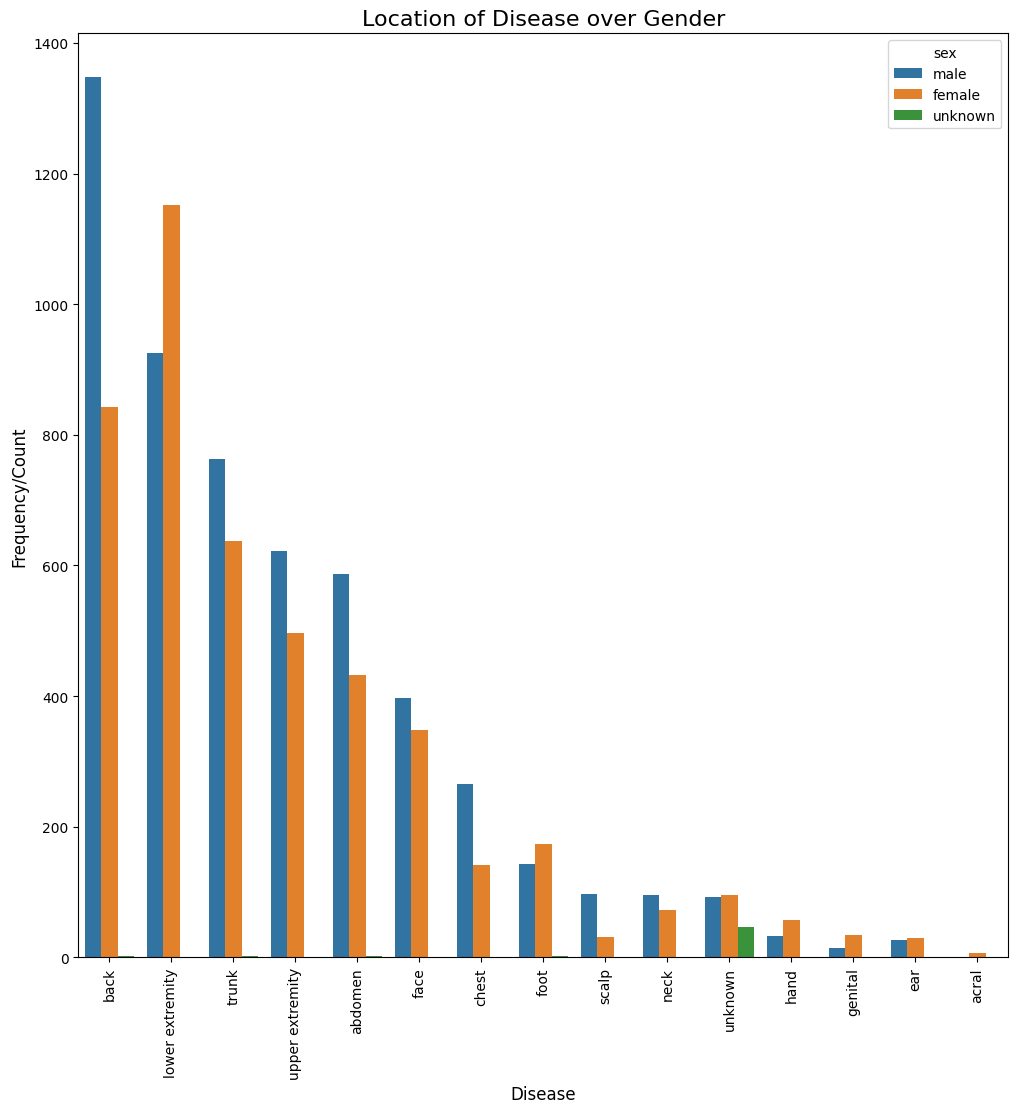

In [ ]:
value = tabular_data[['localization', 'sex']].value_counts().to_frame()
value.reset_index(level=[1, 0], inplace=True)
temp = value.rename(columns={'localization': 'location', 0: 'count'})
plt.figure(figsize=(12, 12))
sns.barplot(x='location', y='count', hue='sex', data=temp)
plt.title('Location of Disease over Gender', size=16)
plt.xlabel('Disease', size=12)
plt.ylabel('Frequency/Count', size=12)
plt.xticks(rotation=90)
plt.show()

In [ ]:
x = data.drop('label', axis=1).values
y = data['label'].values

In [ ]:
x = data.drop('label', axis=1).values
y = data['label'].values
print("Initial x shape:", x.shape)
print("Initial y shape:", y.shape)

Initial x shape: (10015, 2352)
Initial y shape: (10015,)


In [ ]:
if np.any(np.isnan(y)):
    print("NaN values found in y. Removing them.")
    not_nan_indices = ~np.isnan(y)
    x = x[not_nan_indices]
    y = y[not_nan_indices]
    print("x and y after NaN removal:")
    print("x shape:", x.shape)
    print("y shape:", y.shape)

In [ ]:
x = x.reshape(-1, 28, 28, 3)
x = (x - np.mean(x)) / np.std(x)
print("x shape after reshaping and normalization:", x.shape)

x shape after reshaping and normalization: (10015, 28, 28, 3)


In [ ]:
oversample = RandomOverSampler(random_state=42)
x_flattened = x.reshape(x.shape[0], -1)
x_resampled, y_resampled = oversample.fit_resample(x_flattened, y)
x_resampled = x_resampled.reshape(-1, 28, 28, 3)

print("x_resampled shape:", x_resampled.shape)
print("y_resampled shape:", y_resampled.shape)

x_resampled shape: (46935, 28, 28, 3)
y_resampled shape: (46935,)


In [ ]:
X_train, X_temp, Y_train, Y_temp = train_test_split(x_resampled, y_resampled, test_size=0.4, random_state=1)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=1)

print(f"Train dataset length: {len(X_train)}")
print(f"Validation dataset length: {len(X_val)}")
print(f"Test dataset length: {len(X_test)}")
print("Training and Test Split:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

Train dataset length: 28161
Validation dataset length: 9387
Test dataset length: 9387
Training and Test Split:
X_train shape: (28161, 28, 28, 3)
X_test shape: (9387, 28, 28, 3)
Y_train shape: (28161,)
Y_test shape: (9387,)


In [ ]:
model = Sequential([
    Input(shape=(28, 28, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

print("Model Summary:")
model.summary()

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 14, 14, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 897,095 (3.42 MB)

 Trainable params: 897,095 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
callback = ModelCheckpoint(filepath='best_model.keras', monitor='val_accuracy', mode='max', save_best_only=True)
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), batch_size=128, epochs=20, callbacks=[callback])

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9805 - loss: 0.0507 - val_accuracy: 0.9713 - val_loss: 0.1290
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9802 - loss: 0.0495 - val_accuracy: 0.9760 - val_loss: 0.1003
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9848 - loss: 0.0413 - val_accuracy: 0.9762 - val_loss: 0.1092
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9815 - loss: 0.0486 - val_accuracy: 0.9743 - val_loss: 0.1033
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9709 - loss: 0.0823 - val_accuracy: 0.9737 - val_loss: 0.1083
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9845 - loss: 0.0419 - val_accuracy: 0.9782 - val_loss: 0.0911
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9842 - loss: 0.0422 - val_accuracy: 0.9791 - val_loss: 0.0919
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9832 - loss: 0.0440 - val_accu

In [ ]:
best_model = tf.keras.models.load_model('best_model.keras')
loss, acc = best_model.evaluate(X_test, Y_test, verbose=2)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {acc}")

294/294 - 2s - 7ms/step - accuracy: 0.9801 - loss: 0.0858
Test Loss: 0.08577316254377365
Test Accuracy: 0.9800788164138794


In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

metrics_df = pd.DataFrame(metrics_dict)

overall_metrics = pd.DataFrame({
    'Class': ['Overall'],
    'Precision': [precision_score(Y_test, predicted_classes, average='macro')],
    'Recall': [recall_score(Y_test, predicted_classes, average='macro')],
    'F1-Score': [f1_score(Y_test, predicted_classes, average='macro')],
    'Accuracy': [accuracy_score(Y_test, predicted_classes)]
})

metrics_df = pd.concat([metrics_df, overall_metrics], ignore_index=True)

print(metrics_df)


     Class  Precision    Recall  F1-Score  Accuracy
0    akiec   0.993135  1.000000  0.996556  1.000000
1      bcc   0.991392  1.000000  0.995677  1.000000
2      bkl   0.950183  0.982576  0.966108  0.982576
3       df   0.996257  1.000000  0.998125  1.000000
4       nv   0.979083  0.879971  0.926885  0.879971
5     vasc   0.999233  1.000000  0.999616  1.000000
6      mel   0.939331  0.986091  0.962143  0.986091
7  Overall   0.978373  0.978377  0.977873  0.977842


294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy for class akiec (Actinic keratoses and intraepithelial carcinomae): 1.00
Accuracy for class bcc (basal cell carcinoma): 1.00
Accuracy for class bkl (benign keratosis-like lesions): 0.98
Accuracy for class df (dermatofibroma): 1.00
Accuracy for class nv (melanocytic nevi): 0.88
Accuracy for class vasc (pyogenic granulomas and hemorrhage): 1.00
Accuracy for class mel (melanoma): 0.99
Overall Testing Accuracy: 0.98
Classification Report:
                                                   precision    recall  f1-score   support

Actinic keratoses and intraepithelial carcinomae       0.99      1.00      1.00      1302
                            basal cell carcinoma       0.99      1.00      1.00      1382
                   benign keratosis-like lesions       0.95      0.98      0.97      1320
                                  dermatofibroma       1.00      1.00      1.00      1331
                                melanocytic nevi       0.98

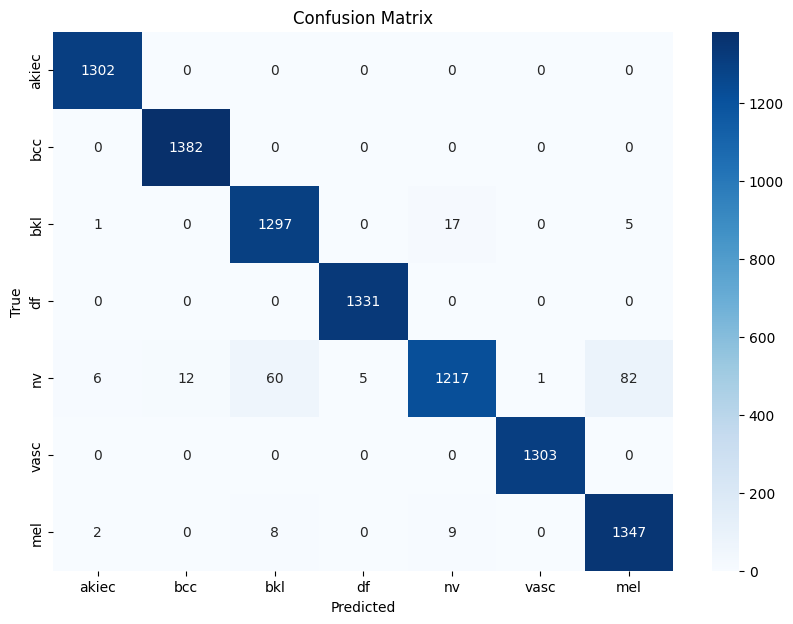

In [ ]:
predictions = best_model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(Y_test, predicted_classes, labels=list(classes.keys()))

class_accuracies = []

for i in range(len(classes)):
    if np.any(Y_test == i):
        idx = np.where(Y_test == i)
        class_accuracy = accuracy_score(Y_test[idx], predicted_classes[idx])
    else:
        class_accuracy = np.nan
    class_accuracies.append(class_accuracy)
    print(f"Accuracy for class {classes[i][0]} ({classes[i][1]}): {class_accuracy:.2f}" if not np.isnan(class_accuracy) else f"Accuracy for class {classes[i][0]} ({classes[i][1]}): Not available")

overall_accuracy = accuracy_score(Y_test, predicted_classes)
print(f"Overall Testing Accuracy: {overall_accuracy:.2f}")

report = classification_report(Y_test, predicted_classes, target_names=[classes[i][1] for i in range(len(classes))])
print("Classification Report:\n", report)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[classes[i][0] for i in range(len(classes))],
            yticklabels=[classes[i][0] for i in range(len(classes))])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
unique, counts = np.unique(Y_test, return_counts=True)
class_distribution = dict(zip(unique, counts))
print("Class distribution in Y_test:", class_distribution)


Class distribution in Y_test: {0.0: 2265, 1.0: 2275, 2.0: 2292, 3.0: 2255, 4.0: 2252, 5.0: 2189, 6.0: 2270}


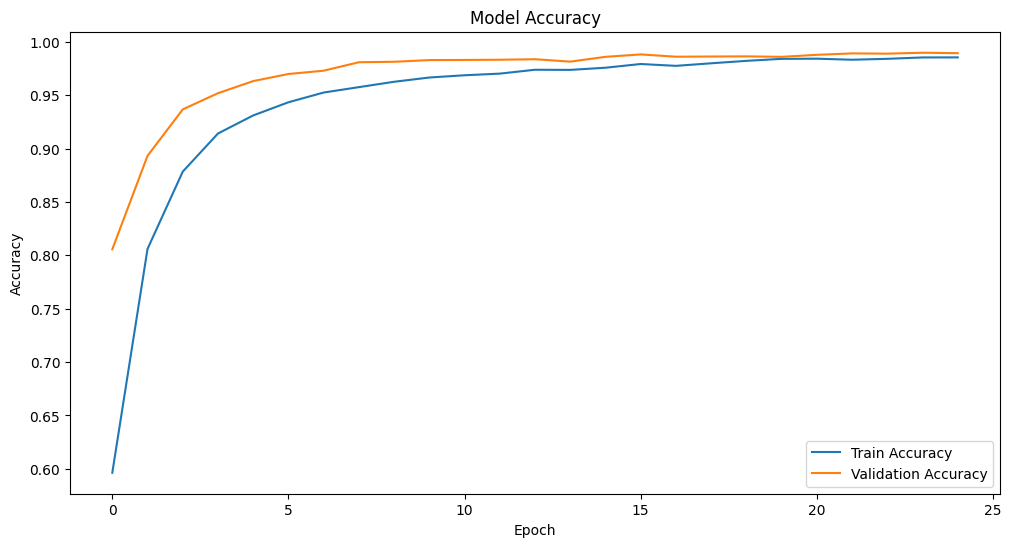

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

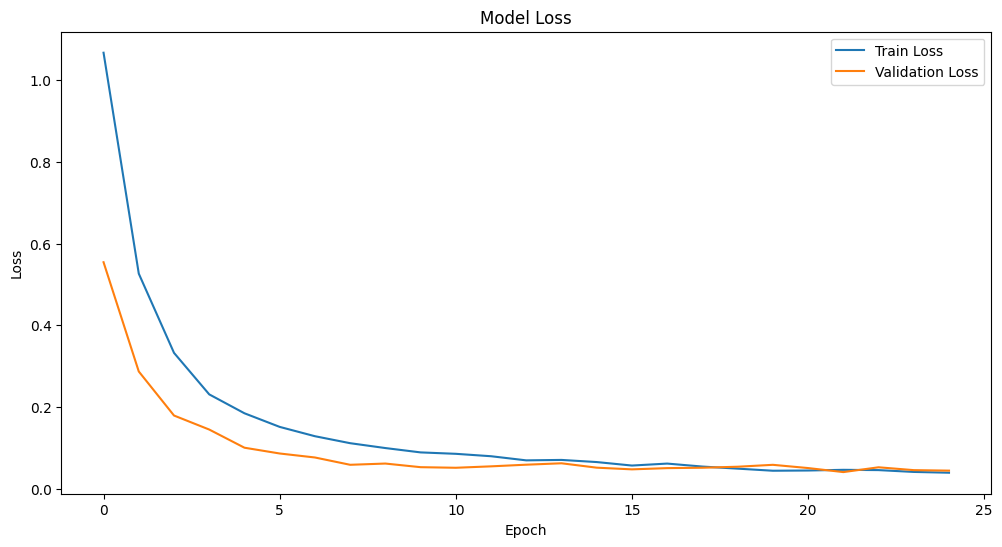

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

494/494 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Visualizing some predictions...


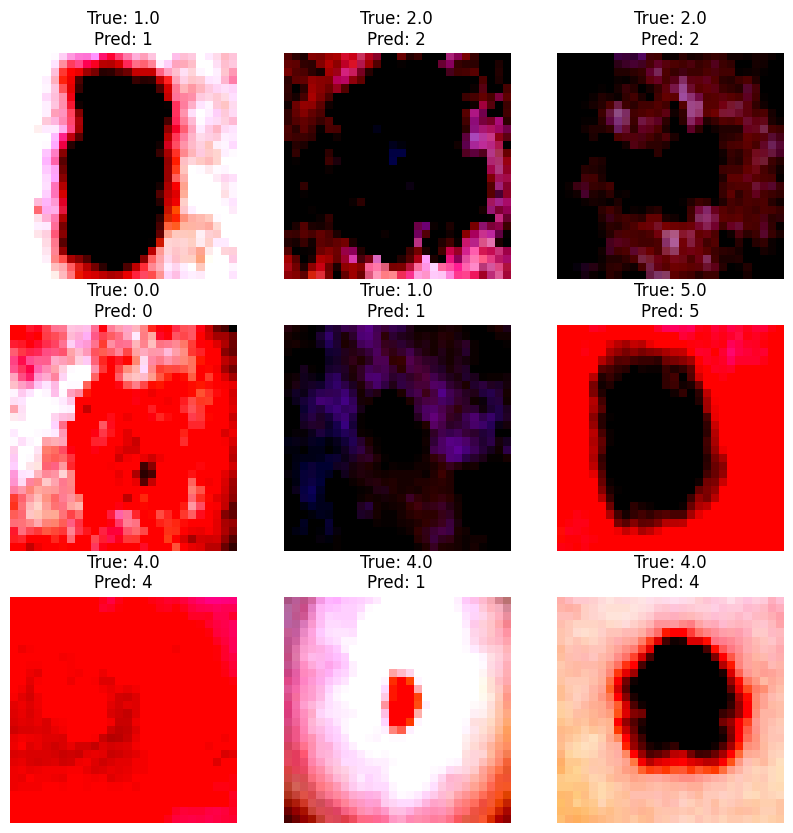

In [ ]:
def plot_images(images, labels, predictions=None):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        title = f"True: {labels[i]}"
        if predictions is not None:
            title += f"\nPred: {predictions[i]}"
        plt.title(title)
        plt.axis('off')
    plt.show()
predictions = best_model.predict(X_test)
predictions = np.argmax(predictions, axis=1)
print("Visualizing some predictions...")
plot_images(X_test[:9], Y_test[:9], predictions[:9])

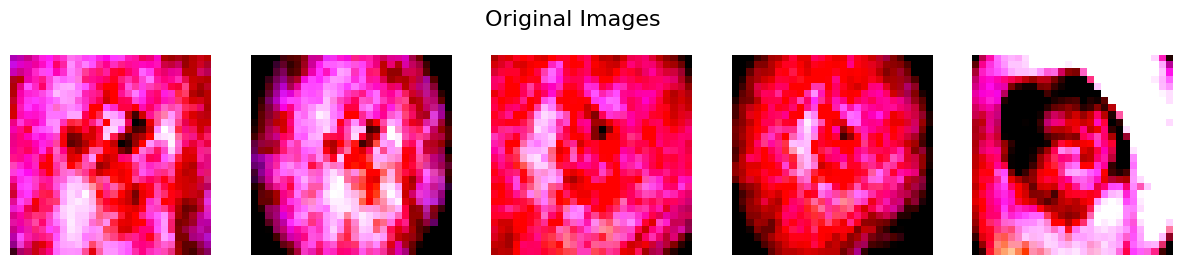

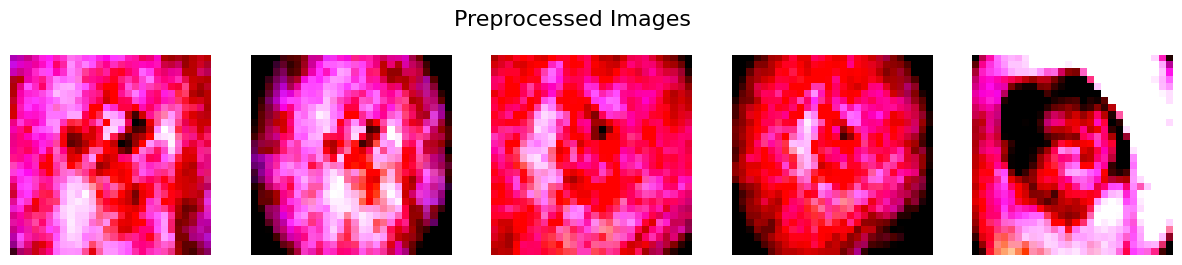

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Original Images', fontsize=16)
for i in range(5):
    axes[i].imshow(x[i])
    axes[i].axis('off')
plt.show()

x = x.reshape(-1, 28, 28, 3)
x = (x - np.mean(x)) / np.std(x)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle('Preprocessed Images', fontsize=16)
for i in range(5):
    axes[i].imshow(x[i])
    axes[i].axis('off')
plt.show()
